# Aprendizaje Automático con Python

### 14 de Mayo del 2026
### TI3002C
### ITESM
### oscarnava@tec.mx


## Entrenando Modelos de Árboles de Decisión y Random Forest en Python

En este notebook, exploraremos cómo entrenar y evaluar modelos de **Árboles de Decisión** y **Random Forest** utilizando Python y la biblioteca `scikit-learn`. Estos algoritmos son muy populares y poderosos para tareas de clasificación. Trabajaremos con un conjunto de datos sintético proporcionado por Liverpool, el cual contiene información sobre marcas, ventas y otras métricas.

El objetivo principal es predecir si una marca **"Renovó"** su registro (nuestra variable objetivo) basándonos en las demás características del dataset.

In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Configurar el estilo de los gráficos
sns.set_style('whitegrid')

### Carga y Exploración de Datos
Comenzaremos cargando una muestra del dataset provisto y explorando sus características básicas para entender con qué estamos trabajando.

In [ ]:
df = pd.read_csv("base_entrenamiento_optimizada_2.csv")
# Mostrar las primeras filas del dataset
display(df.head())

,denominacion,descripcion,total_sales,revenue,antiguedad_de_la_marca,numero_de_leads_en_web,calificacion_promedio_de_productos,numero_de_devoluciones,renovo,participacion_de_mercado_(%),avg_market_share,crecimiento_total_sales,pct_costo,costo_por_pieza,costo_ops_total,margen_neto_marca,revenue_por_lead,ratio_devolucion_revenue,roi_marca,ratio_dev_revenue
0,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",335.125000,7.340517e+04,7,52.250000,3.254327,56.750000,si,0.001140,0.001137,-0.017314,0.42,30,4.088392e+04,0.443038,1378.500785,0.000773,0.795434,0.000773
1,#OCTUBREROSA CUIDATE,PUBLICIDAD; GESTION DE NEGOCIOS COMERCIALES; A...,321.875000,9.277497e+04,7,63.000000,3.198713,51.750000,si,0.001505,0.001479,-0.128812,0.15,30,2.357250e+04,0.745918,1449.608892,0.000558,2.935605,0.000558
2,#ZONA D,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",172.000000,7.223436e+04,11,29.272727,2.327540,30.272727,no,0.001579,0.001627,-0.373398,0.42,65,4.151843e+04,0.425226,2386.119982,0.000419,0.739796,0.000419
3,#ZONA D,"PUBLICIDAD, GESTION DE NEGOCIOS COMERCIALES, A...",430.090909,7.795504e+04,11,68.000000,2.318617,76.818182,no,0.001645,0.001705,-0.333679,0.15,65,3.964917e+04,0.491384,1129.783243,0.000985,0.966096,0.000985
4,1 TO 9,"VESTUARIO CASUAL, INFORMAL, DE GALA, DEPORTIVO...",59238.466670,7.772100e+06,29,23615.400000,4.296330,3036.300000,si,0.157607,0.159221,0.224401,0.42,30,5.041436e+06,0.351342,329.097571,0.000391,0.541644,0.000391


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   denominacion                        2764 non-null   object 
 1   descripcion                         2764 non-null   object 
 2   total_sales                         2764 non-null   float64
 3   revenue                             2764 non-null   float64
 4   antiguedad_de_la_marca              2764 non-null   int64  
 5   numero_de_leads_en_web              2764 non-null   float64
 6   calificacion_promedio_de_productos  2764 non-null   float64
 7   numero_de_devoluciones              2764 non-null   float64
 8   renovo                              2764 non-null   object 
 9   participacion_de_mercado_(%)        2764 non-null   float64
 10  avg_market_share                    2764 non-null   float64
 11  crecimiento_total_sales             2764 no

### Preprocesamiento de Datos
Antes de entrenar los modelos necesitamos:
1. Seleccionar las características principales (*features*) y lo que queremos predecir (*target*).
2. Convertir los valores de texto de la columna a predecir (`si`/`no`) en valores binarios (`1`/`0`).
3. Dividir el conjunto total en un grupo de **entrenamiento** (para que los modelos aprendan) y otro grupo de **prueba** (para medir qué tan bien aprendieron).

In [ ]:
# 1. Separar características (X) y la variable objetivo (y)
features = ['total_sales',
'revenue',
'antiguedad_de_la_marca',
'numero_de_leads_en_web',
'calificacion_promedio_de_productos',
'numero_de_devoluciones',
'participacion_de_mercado_(%)',
'avg_market_share',
'crecimiento_total_sales',
'pct_costo',
'costo_ops_total',
'margen_neto_marca',
'revenue_por_lead',
'ratio_devolucion_revenue',
'roi_marca',
'ratio_dev_revenue']
target = 'renovo'

X = df[features]
y = df[target]

# 2. Mapear la variable objetivo a valores numéricos (si=1, no=0)
y = y.map({'si': 1, 'no': 0})

# 3. Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")

Tamaño del conjunto de entrenamiento (X_train): (1934, 16)
Tamaño del conjunto de prueba (X_test): (830, 16)


### Modelo Random Forest (Bosque Aleatorio)
El modelo de *Random Forest* construye una multitud de árboles de decisión en la fase de entrenamiento y nos entrega el promedio o mayoría de sus decisiones. Esto ayuda a prevenir el sobreajuste que veíamos en los árboles de decisión individuales.

In [ ]:
# Inicializar y entrenar el modelo Random Forest
# 'n_estimators' define la cantidad de árboles de decisión que crearán el "bosque"
rf_model = RandomForestClassifier(random_state=3002, n_estimators=100)
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

#### Evaluación del Random Forest
Comparamos los resultados para ver si construir múltiples árboles (Random Forest) nos ofreció un mejor desempeño.

--- Métricas de Random Forest ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       229
           1       0.99      0.97      0.98       601

    accuracy                           0.97       830
   macro avg       0.96      0.97      0.96       830
weighted avg       0.97      0.97      0.97       830

Especificidad: 0.98


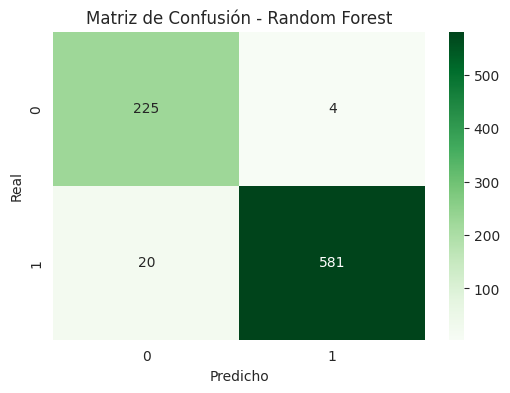

In [ ]:
print("--- Métricas de Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# Cálculo de Especificidad
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
specificity_rf = tn / (tn + fp)
print(f"Especificidad: {specificity_rf:.2f}")

# Matriz de Confusión para Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Persistencia del Modelo
Para evitar reentrenar el modelo cada vez que necesitemos usarlo, podemos guardarlo en un archivo utilizando la biblioteca `joblib`. Esto permite exportar el modelo entrenado y cargarlo posteriormente en este o en otros entornos.

In [ ]:
y_pred = rf_model.predict(df[features][0:3])

In [ ]:
import joblib

# Guardar el modelo Random Forest (o el de tu elección)
filename = 'random_forest_model_Equipo_alfa_buena_maravilla_onda_dinamita_escuadrón_lobo.joblib'
joblib.dump(rf_model, filename)
print(f"Modelo '{filename}' guardado exitosamente.")

Modelo 'random_forest_model_Equipo_alfa_buena_maravilla_onda_dinamita_escuadrón_lobo.joblib' guardado exitosamente.


In [ ]:
import joblib

# Guardar el modelo Random Forest (o el de tu elección)
filename = 'random_forest_model_Equipo_alfa_buena_maravilla_onda_dinamita_escuadrón_lobo.joblib'
joblib.dump(rf_model, filename)
print(f"Modelo '{filename}' guardado exitosamente.")

# Cargar el modelo guardado
loaded_model = joblib.load(filename)
print(f"Modelo '{filename}' cargado exitosamente.")

# Demostrar que el modelo cargado puede hacer predicciones
y_pred_loaded = loaded_model.predict(df[features][0:3])
print("\nPredicciones con el modelo cargado (Random Forest):")
print(y_pred_loaded)

# Comparar con las predicciones originales del modelo Random Forest
import numpy as np
print("¿Las predicciones del modelo cargado son idénticas a las originales?", np.array_equal(y_pred, y_pred_loaded))

Modelo 'random_forest_model_Equipo_alfa_buena_maravilla_onda_dinamita_escuadrón_lobo.joblib' guardado exitosamente.
Modelo 'random_forest_model_Equipo_alfa_buena_maravilla_onda_dinamita_escuadrón_lobo.joblib' cargado exitosamente.

Predicciones con el modelo cargado (Random Forest):
[1 1 0]
¿Las predicciones del modelo cargado son idénticas a las originales? True


### Pruebas de Predicción
Una vez que el modelo está cargado, es importante validar que funciona correctamente realizando predicciones con datos nuevos o específicos.

#### 1. Predicción Individual (1 a 1)
En este escenario, simulamos la entrada de un solo registro manual para observar la respuesta del modelo en tiempo real.

In [ ]:
# 1 a 1

registro_marca = {'total_sales':335.125 ,
                  'revenue':73405.16683,
                  'antiguedad_de_la_marca':7,
                  'numero_de_leads_en_web':52.25,
                  'calificacion_promedio_de_productos':3.254327093,
                  'numero_de_devoluciones':56.75,
                  'participacion_de_mercado_(%)':0.001139676,
                  'avg_market_share':0.001137125,
                  'crecimiento_total_sales':-0.017313887,
                  'pct_costo':0.42,
                  'costo_ops_total':40883.92007,
                  'margen_neto_marca':0.44303757,
                  'revenue_por_lead':1378.500785,
                  'ratio_devolucion_revenue':0.000773096,
                  'roi_marca':0.795433786,
                  'ratio_dev_revenue':0.000773096}
predicción = loaded_model.predict(np.array(list(registro_marca.values())).reshape(1, -1))
print(registro_marca)
print(predicción)


{'total_sales': 335.125, 'revenue': 73405.16683, 'antiguedad_de_la_marca': 7, 'numero_de_leads_en_web': 52.25, 'calificacion_promedio_de_productos': 3.254327093, 'numero_de_devoluciones': 56.75, 'participacion_de_mercado_(%)': 0.001139676, 'avg_market_share': 0.001137125, 'crecimiento_total_sales': -0.017313887, 'pct_costo': 0.42, 'costo_ops_total': 40883.92007, 'margen_neto_marca': 0.44303757, 'revenue_por_lead': 1378.500785, 'ratio_devolucion_revenue': 0.000773096, 'roi_marca': 0.795433786, 'ratio_dev_revenue': 0.000773096}
[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#### 2. Predicción en Lote (Batch)
Finalmente, cargamos un archivo de Excel con múltiples registros, aplicamos la limpieza necesaria para que coincida con las características (*features*) del entrenamiento y realizamos predicciones masivas.

In [ ]:
import pandas as pd

# Batch Data

batch_data_df = pd.read_csv("batch nuevo super mega nuevo .csv")

# Select only the features that the model was trained on
# The 'features' list is defined earlier in the notebook
batch_data_for_prediction = batch_data_df[features]

batch_data_for_prediction.head()
loaded_model.predict(batch_data_for_prediction)

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1])